In [1]:
import torch
import stable_worldmodel as swm
from sigreg import SIGReg 
from torch.distributions.normal import Normal
from torch.linalg import vector_norm
#from model import WorldModel

In [2]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from collections import OrderedDict

class ActionEmbedder(nn.Module):
    def __init__(self, action_size, hidden_dim):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(action_size,hidden_dim),
            nn.SiLU()
        )
    def forward(self, x):
        return self.embed(x)

class Attention(nn.Module):
    def __init__(self, hidden_dim, nb_heads):
        super().__init__()
        self.attention = nn.MultiheadAttention(hidden_dim, nb_heads, batch_first=True)

    def forward(self, x):
        return self.attention(x,x,x, need_weights=False)[0]

class CausalAttention(nn.Module):
    def __init__(self, hidden_dim, nb_heads, p_dropout):
        super().__init__()
        self.attention = nn.MultiheadAttention(hidden_dim, nb_heads, batch_first=True, dropout=p_dropout)

    def forward(self, x):
        return self.attention(x,x,x, need_weights=False, is_causal=True, attn_mask=nn.modules.transformer.Transformer.generate_square_subsequent_mask(x.shape[-2]))[0]

class Patch(nn.Module):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def forward(self, x):
        B,C,H,W = x.shape
        P = self.patch_size
        N = H*W//(P**2)
        x = x.reshape(B,C,H//P,P,W//P,P)
        x = x.permute(0,2,4,1,3,5)
        x = x.reshape(B,N,-1)
        return x


class Predictor(nn.Module):
    def __init__(self, hidden_dim, nb_layers, p_dropout, nb_heads):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.condition = nn.Linear(hidden_dim, 6*hidden_dim)
        with torch.no_grad():
            for p in self.condition.parameters():
                p.zero_()
        self.layers = nn.ModuleList([
             nn.ModuleDict({
                'norm1': nn.LayerNorm(hidden_dim,elementwise_affine=False),
                'att': CausalAttention(hidden_dim, nb_heads, p_dropout),
                'norm2': nn.LayerNorm(hidden_dim,elementwise_affine=False),
                'ffn': nn.Sequential(nn.Linear(hidden_dim, 4*hidden_dim), nn.GELU(), nn.Linear(4*hidden_dim, hidden_dim)),
             }) for _ in range(nb_layers)
        ])
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(p_dropout)

    def forward(self, x, action):
        # x.shape = B * T * D
        # action.shape = B * T * D
        alpha1,beta1,gamma1,alpha2,beta2,gamma2 = self.condition(action).chunk(6,-1)
        for layer in self.layers:
            x = self.dropout(layer['att'](layer['norm1'](x)*(1.0+gamma1)+beta1))*alpha1+x
            x = self.dropout(layer['ffn'](layer['norm2'](x)*(1.0+gamma2)+beta2))*alpha2+x
        return self.layer_norm(x)


class ViT(nn.Module):
    def __init__(self, hidden_dim, patch_size, channels, nb_heads, nb_layers, height, width):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.patch_size = patch_size
        self.channels = channels
        self.height = height
        self.width = width
        self.embedding = nn.Linear(patch_size**2*channels,hidden_dim)
        self.xclass = nn.Parameter(torch.randn(hidden_dim))
        n = height*width // (patch_size**2)
        self.pos_enc = nn.Parameter(torch.randn(n+1,hidden_dim))
        self.patch = Patch(patch_size)
        self.layers = nn.ModuleList([
             nn.ModuleDict({
                'norm1': nn.LayerNorm(hidden_dim),
                'att': Attention(hidden_dim, nb_heads),
                'norm2': nn.LayerNorm(hidden_dim),
                'ffn': nn.Sequential(nn.Linear(hidden_dim, 4*hidden_dim), nn.GELU(), nn.Linear(4*hidden_dim, hidden_dim)),
             }) for _ in range(nb_layers)
        ])
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.last_layer_mlp = nn.Linear(hidden_dim, hidden_dim)
        self.batch_norm = nn.BatchNorm1d(hidden_dim)
    
    def forward(self, x):
        # x.shape = bs * c * height * weight
        p = self.patch_size
        c = self.channels
        n = x.shape[2]*x.shape[3]//(p**2)
        x = self.patch(x)
        x = torch.concat([self.xclass.expand(x.shape[0], 1, -1), self.embedding(x)], dim=-2)+self.pos_enc
        for layer in self.layers:
            x = layer['att'](layer['norm1'](x))+x
            x = layer['ffn'](layer['norm2'](x))+x
        return self.batch_norm(self.last_layer_mlp(self.layer_norm(x)[:,0,:]))


class WorldModel(nn.Module):
    def __init__(self, hidden_dim, patch_size, channels, enc_nb_heads, enc_nb_layers, height, width, pred_nb_layers, pred_p_dropout, pred_nb_heads, action_dim):
        super().__init__()
        self.encoder = ViT(hidden_dim, patch_size, channels, enc_nb_heads, enc_nb_layers, height, width)
        self.predictor = Predictor(hidden_dim, pred_nb_layers, pred_p_dropout, pred_nb_heads)
        self.action_embedder = ActionEmbedder(action_dim, hidden_dim)

    def forward(self, frames, actions):
        # frames.shape = B * T * C * H * W
        # actions.shape = B * T * action_dim
        actions = self.action_embedder(actions) # B * T * D
        frames = self.encode_frames(frames)
        predicted = self.predictor(frames, actions)
        return predicted, frames

    def encode_frames(self, frames):
        B,T,C,H,W = frames.shape
        frames = frames.reshape(-1, C, H, W) # (B*T)*C*H*W
        frames = self.encoder(frames)
        frames = frames.reshape(B,T,frames.shape[-1])
        return frames

    def rollout(self, start, actions, H):
        # start.shape = B * D
        # actions.shape = B * T * action_dim
        B, T, action_dim = actions.shape
        pred = None
        actions = self.action_embedder(actions)
        frames = [start.expand(B, 1, -1)]
        for i in range(H):
            t_frames = torch.cat(frames, dim=1)
            pred = self.predictor(t_frames, actions[:,0:i+1,:])
            frames.append(pred[:,-1:,:])
        return pred[:,-1,:]
        

In [3]:
device = 'mps'
num_epochs = 10

In [4]:
dataset = swm.data.load_dataset(
    'tutorial_pusht.lance',
    num_steps=6,
    frameskip=5,
    keys_to_load=['pixels', 'action', 'state'],
)

In [8]:
action_dim = 2*5

In [9]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    drop_last=True,
)


In [14]:
model = WorldModel(
    hidden_dim=192, 
    patch_size=12,
    channels=3, 
    enc_nb_heads=3, 
    enc_nb_layers=12, 
    height=96, 
    width=96, 
    pred_nb_layers=6, 
    pred_p_dropout=0.1, 
    pred_nb_heads=16, 
    action_dim=action_dim
).to(device)

In [7]:
#model = model.load_state_dict(torch.load('./model-1.pt'))

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [16]:
losses = []

In [17]:
for epoch in tqdm(range(num_epochs), desc="training"):
    for batch in loader:
        optimizer.zero_grad()
        frames = batch['pixels'].to(device).type(torch.float32)
        actions = torch.nan_to_num(batch['action'], 0.0).to(device).type(torch.float32)
        pred, embeds = model(frames, actions)
        sigregloss = SIGReg(embeds.reshape(-1, embeds.shape[-1]))
        mseloss = F.mse_loss(pred[:,0:-2,:], embeds[:,1:-1,:])
        loss = mseloss + 0.1*sigregloss
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    scheduler.step()

training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [46:54<00:00, 281.48s/it]


In [18]:
import matplotlib.pyplot as plt

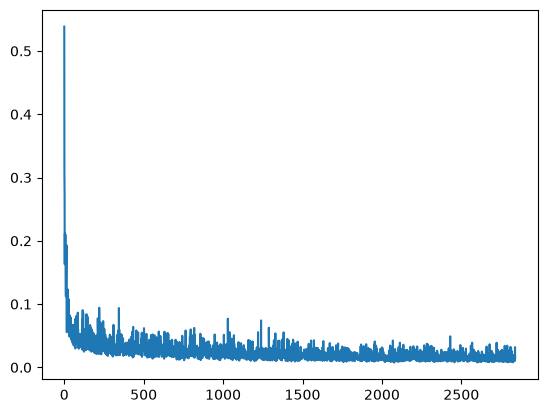

In [19]:
plt.plot(losses)

In [20]:
torch.save(model.state_dict(), f'model-{num_epochs}.pt')

In [21]:
def CEM(model, H, N, K, T, action_dim, start, goal):
    means = [torch.zeros(H, action_dim).to(device)]
    stds = [torch.ones(H, action_dim).to(device)]
    best_action_sequence, min_cost = None, float('inf')
    for t in range(T):
        distribution = Normal(means[-1], stds[-1])
        candidates = distribution.sample((N,)).to(device)
        destinations = model.rollout(start, candidates, H)
        costs = vector_norm((goal.expand(N, -1) - destinations), dim=1)
        elite_costs, elite = torch.topk(costs, k=K, largest=False)
        mean = candidates[elite].mean(dim=0)
        std = candidates[elite].std(dim=0)
        means.append(mean)
        stds.append(std)
        if elite_costs[0] < min_cost:
            best_action_sequence = candidates[elite[0]]
            min_cost = elite_costs[0]
    return best_action_sequence

In [22]:
batch = next(iter(loader))

In [23]:
frames = batch['pixels'].to(device).type(torch.float32)

In [24]:
with torch.no_grad():
    model.eval()
    start = model.encode_frames(frames[0][0].expand(1, 1, -1, -1, -1))
    goal = model.encode_frames(frames[0][-1].expand(1, 1, -1, -1, -1))

In [25]:
CEM(model, H=5, N=300, K=30, T=30, action_dim=action_dim, start=start.view(1, -1), goal=goal.view(1, -1))

tensor([[-0.0221,  0.7770,  1.1023,  0.4479,  0.1415, -0.5571,  0.3173, -1.0050,
         -0.3235,  0.1139],
        [-0.5980, -0.3387, -0.8409, -0.8649, -0.1553,  0.5850,  0.2937, -0.0833,
         -0.0574, -0.0264],
        [ 0.5886, -0.1234,  0.0771, -0.9364, -0.4647, -0.5452,  0.8097,  0.6287,
          0.0375,  0.2608],
        [-0.3685,  0.3802,  0.4256,  0.9777,  0.1085, -0.6759,  0.6125,  0.6727,
          0.4518,  0.3634],
        [ 0.7278, -0.3289,  0.3861,  0.8277,  0.0028,  0.5105,  1.1486, -0.5457,
         -0.6183,  0.5390]], device='mps:0')